# Eksplorativna Analiza Podataka (EDA)
**Dataset:** Credit Card Fraud Detection (Kaggle — ULB MLG)

## Opis skupa podataka

Skup podataka Credit Card Fraud Detection sadrži transakcije izvršene kreditnim karticama evropskih korisnika tokom dva dana u septembru 2013. godine. Dataset obuhvata ukupno 284.807 transakcija, od kojih je samo 492 označeno kao prevara. Podaci su izrazito nebalansirani jer fraudulentne transakcije čine približno 0,17% svih transakcija. Zbog toga je ovaj skup podataka pogodan za primenu metoda mašinskog učenja u detekciji finansijskih prevara.

U ovom delu analiziraćemo skup podataka sa kojim radimo kako bismo stekli jasnije razumevanje njegove strukture i karakteristika. Fokus će biti na osnovnim statističkim pregledima, distribuciji varijabli, kao i identifikaciji potencijalnih outliera i anomalija. Kroz vizualizacije i deskriptivnu analizu cilj je da bolje razumemo obrasce u podacima, odnose između promenljivih i eventualne razlike između klasa, što predstavlja osnovu za dalju analizu i izgradnju modela.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats
import warnings

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Učitavanje podataka

In [3]:
DATA_PATH = '../data/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Opis kolona

Skup podataka sadrži ukupno 31 kolonu. Kolone **V1–V28** predstavljaju anonimne promenljive dobijene primenom metode PCA (Principal Component Analysis) radi zaštite privatnosti korisnika. Kolona **Time** predstavlja broj sekundi proteklih od prve transakcije u skupu podataka, dok **Amount** označava iznos transakcije. Ciljna promenljiva **Class** označava tip transakcije, gde vrednost 0 predstavlja regularnu transakciju, a vrednost 1 prevaru.

## 2. Osnovna inspekcija


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
print(f'Ukupno NaN: {df.isnull().sum().sum()}')
print(f'Duplikati: {df.duplicated().sum()}')

Ukupno NaN: 0
Duplikati: 1081


## 3. Analiza ciljne promenljive

        Count  Percentage (%)
Class                        
0      284315         99.8273
1         492          0.1727


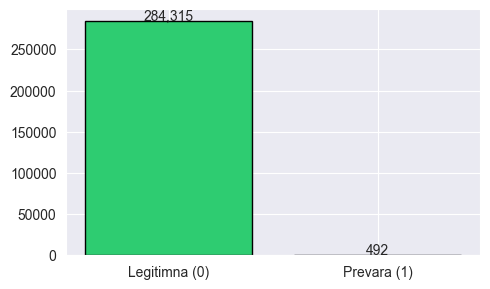

577


In [7]:
class_counts = df['Class'].value_counts().sort_index()
class_pct = df['Class'].value_counts(normalize=True).sort_index() * 100

print(pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(4)
}))

fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(['Legitimna (0)', 'Prevara (1)'],
       class_counts.values,
       color=['#2ecc71', '#e74c3c'],
       edgecolor='black')

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

ratio = class_counts.loc[0] // class_counts.loc[1]
print(ratio)

Na svakih 577 legitimnih transakcija postoji 1 prevara. Ovo predstavlja centralni problem ovog dataseta. Od ukupno 284315 transakcija, samo 492 su prevare, što znači da bi model, čak i ako uvek predviđa „legitimne” transakcije, imao tačnost od 99.83%, ali ne bi uhvatio nijednu prevaru. Zbog toga se kao metrika ne koristi accuracy, već precision, F1-score i recall.

## 4. Time i Amount feature



In [8]:
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


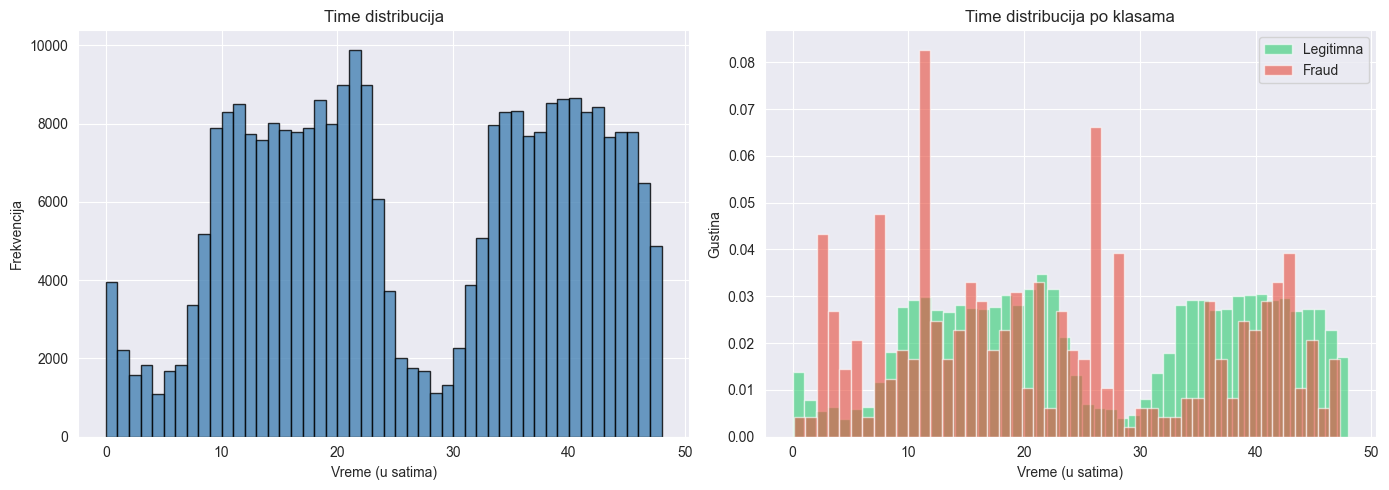

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Time'] / 3600, bins=48, color='steelblue',edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Vreme (u satima)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Time distribucija')

for cls, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Legitimna', 'Fraud']):
    axes[1].hist(df[df['Class'] == cls]['Time'] / 3600,
                 bins=48, alpha=0.6, color=color, label=label, density=True)

axes[1].set_xlabel('Vreme (u satima)')
axes[1].set_ylabel('Gustina')
axes[1].set_title('Time distribucija po klasama')
axes[1].legend()

plt.tight_layout()
plt.show()

Distribucija Time varijable pokazuje dve jasne koncentracije, što sugeriše postojanje cikličnog obrasca aktivnosti tokom dana i noći.
Gustina svakog bin-a u drugom histogramu računa se prema sledećoj formuli:

$$
Gustina = \frac{\text{Broj posmatranja u intervalu}}
{\text{Ukupan broj posmatranja} \times \text{Širina intervala}}
$$

Ova normalizacija obezbeđuje da ukupna površina ispod histograma bude jednaka 1, što omogućava poređenje raspodela čak i kada klase imaju različit broj uzoraka.

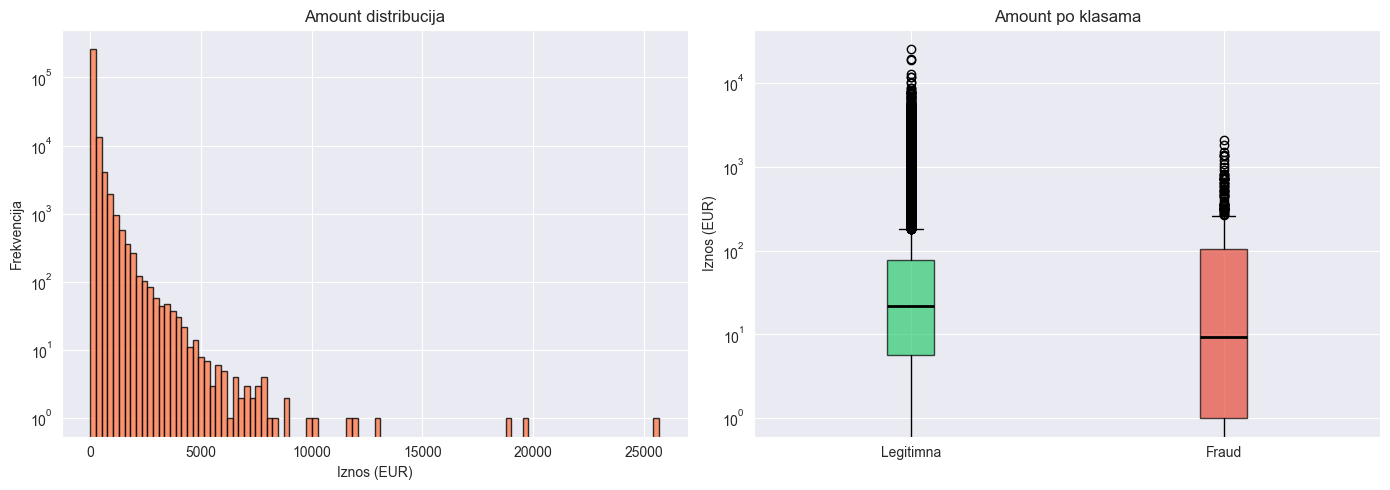

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=100, color='coral',edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Iznos (EUR)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Amount distribucija')
axes[0].set_yscale('log')

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

bp = axes[1].boxplot([legit, fraud],tick_labels=['Legitimna', 'Fraud'],patch_artist=True,medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.7)

bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.7)

axes[1].set_ylabel('Iznos (EUR)')
axes[1].set_title('Amount po klasama')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

Iz raspodele Amount varijable jasno se uočava desno-asimetrična distribucija, sa repom ka većim vrednostima. Takođe, poređenjem medijana između legitimnih i fraud transakcija vidi se da su vrednosti kod prevara niže. Ovakav obrazac može se interpretirati kroz ponašanje prevaranata, koji često započinju manjim transakcijama kako bi testirali sistem i smanjili rizik od otkrivanja.

## 5. Identifikacija najdiskriminativnijih featuera

In [11]:
FEATURES = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

results = []
for feat in FEATURES:
    f_vals = fraud[feat]
    l_vals = legit[feat]
    mean_diff = f_vals.mean() - l_vals.mean()
    pooled_std = np.sqrt(
        (f_vals.var() * len(f_vals) + l_vals.var() * len(l_vals))
        / (len(f_vals) + len(l_vals))
    )
    effect_size = mean_diff / pooled_std if pooled_std > 0 else 0
    _, p_value = stats.mannwhitneyu(f_vals, l_vals, alternative='two-sided')

    results.append({
        'Feature'              : feat,
        'Mean (Fraud)'         : round(f_vals.mean(), 4),
        'Mean (Legit)'         : round(l_vals.mean(), 4),
        'Mean Diff'            : round(mean_diff, 4),
        'Effect Size (Cohen d)': round(effect_size, 4),
        'Abs Effect'           : round(abs(effect_size), 4),
        'p-value'              : p_value,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('Abs Effect', ascending=False)
    .reset_index(drop=True)
)

results_df.index += 1
print(f"Statistički značajni featurei (p < 0.05): "
      f"{(results_df['p-value'] < 0.05).sum()} / {len(results_df)}")
print()

results_df.drop(columns='p-value').style \
    .background_gradient(cmap='RdYlGn', subset=['Abs Effect']) \
    .background_gradient(cmap='RdBu',   subset=['Effect Size (Cohen d)']) \
    .format({'Mean Diff': '{:+.4f}', 'Effect Size (Cohen d)': '{:+.4f}'})

Statistički značajni featurei (p < 0.05): 27 / 30



,Feature,Mean (Fraud),Mean (Legit),Mean Diff,Effect Size (Cohen d),Abs Effect
1,V17,-6.665800,0.011500,-6.6774,-8.3165,8.316500
2,V14,-6.971700,0.012100,-6.9838,-7.6434,7.643400
3,V12,-6.259400,0.010800,-6.2702,-6.4995,6.499500
4,V10,-5.676900,0.009800,-5.6867,-5.3498,5.349800
5,V16,-4.139900,0.007200,-4.1471,-4.8268,4.826800
6,V3,-7.033300,0.012200,-7.0455,-4.7354,4.735400
7,V7,-5.568700,0.009600,-5.5784,-4.5902,4.590200
8,V11,3.800200,-0.006600,+3.8067,+3.7750,3.775000
9,V4,4.542000,-0.007900,+4.5499,+3.2425,3.242500
10,V18,-2.246300,0.003900,-2.2502,-2.7014,2.701400


Za ovu analizu primenjen je Mann–Whitney U test, neparametarski statistički test koji ispituje da li postoje razlike u distribucijama dve nezavisne grupe - u ovom slučaju fraud i legitimnih transakcija. Test je primenjen za svaki od 30 feature-a, a rezultati su zatim rangirani na osnovu effect size-a (Cohen-ove d mere), koji predstavlja standardizovanu razliku između sredina dve grupe, odnosno meri koliko je razlika jaka u odnosu na varijabilnost podataka (ne samo kolika je apsolutna razlika). Na ovaj način izdvojeni su feature-i koji najjače razdvajaju klase, pri čemu su V17, V14, V12 i V10 izdvojeni kao najdiskriminativniji.

Ova analiza je značajna jer omogućava identifikaciju ključnih varijabli koje najviše doprinose razdvajanju fraud i legit transakcija, što predstavlja osnovu za dalju izgradnju i optimizaciju modela za detekciju prevara.

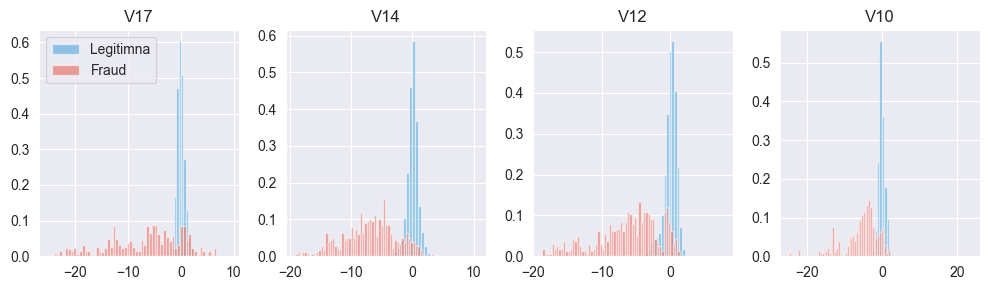

In [12]:
v_features = [f'V{i}' for i in range(1, 29)]

top_feats = ['V17', 'V14', 'V12','V10']

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    for cls, color, label in zip([0, 1], ['#3498db', '#e74c3c'], ['Legitimna', 'Fraud']):
        axes[i].hist(df[df['Class'] == cls][feat],
                     bins=60, alpha=0.5, density=True,
                     color=color, label=label)

    axes[i].set_title(feat)

axes[0].legend()
plt.tight_layout()
plt.show()

Takođe, vizuelna analiza ovih rezultata pokazuje jasno razdvajanje distribucija između klasa, što dodatno potvrđuje da su posmatrani feature-i među najjačim diskriminatorima. Što je razlika između raspodela veća i preklapanje manje, to je značaj datog feature-a za razdvajanje fraud i legitimnih transakcija veći.

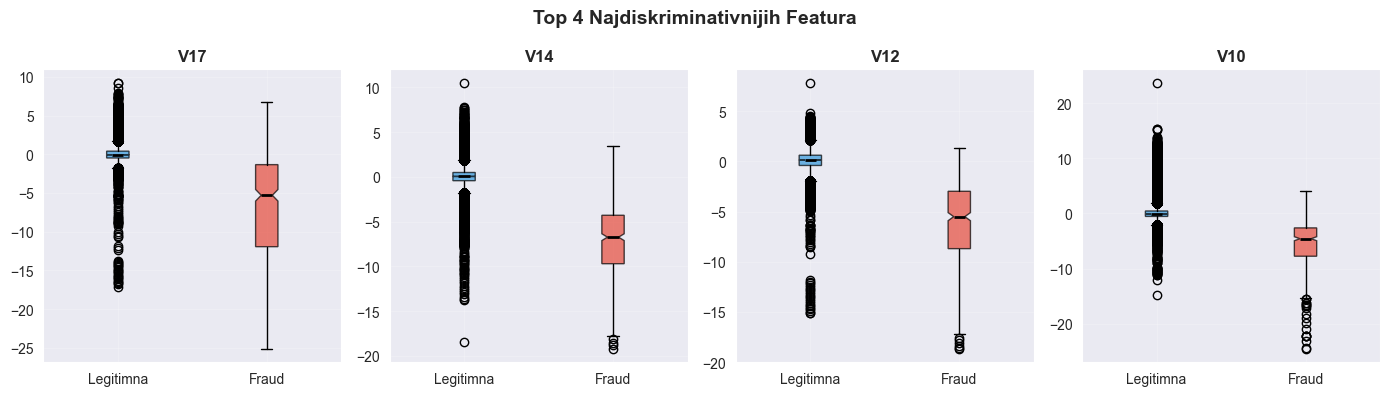

In [13]:
top_features = results_df.head(4)['Feature'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = [
        df[df['Class'] == 0][feat],
        df[df['Class'] == 1][feat]
    ]
    bp = axes[i].boxplot(
        data,
        tick_labels=['Legitimna', 'Fraud'],
        patch_artist=True,
        notch=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)

    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)

    axes[i].set_title(feat, fontweight='bold')
    axes[i].grid(alpha=0.2)

plt.suptitle('Top 4 Najdiskriminativnijih Featura', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Korelaciona matrica

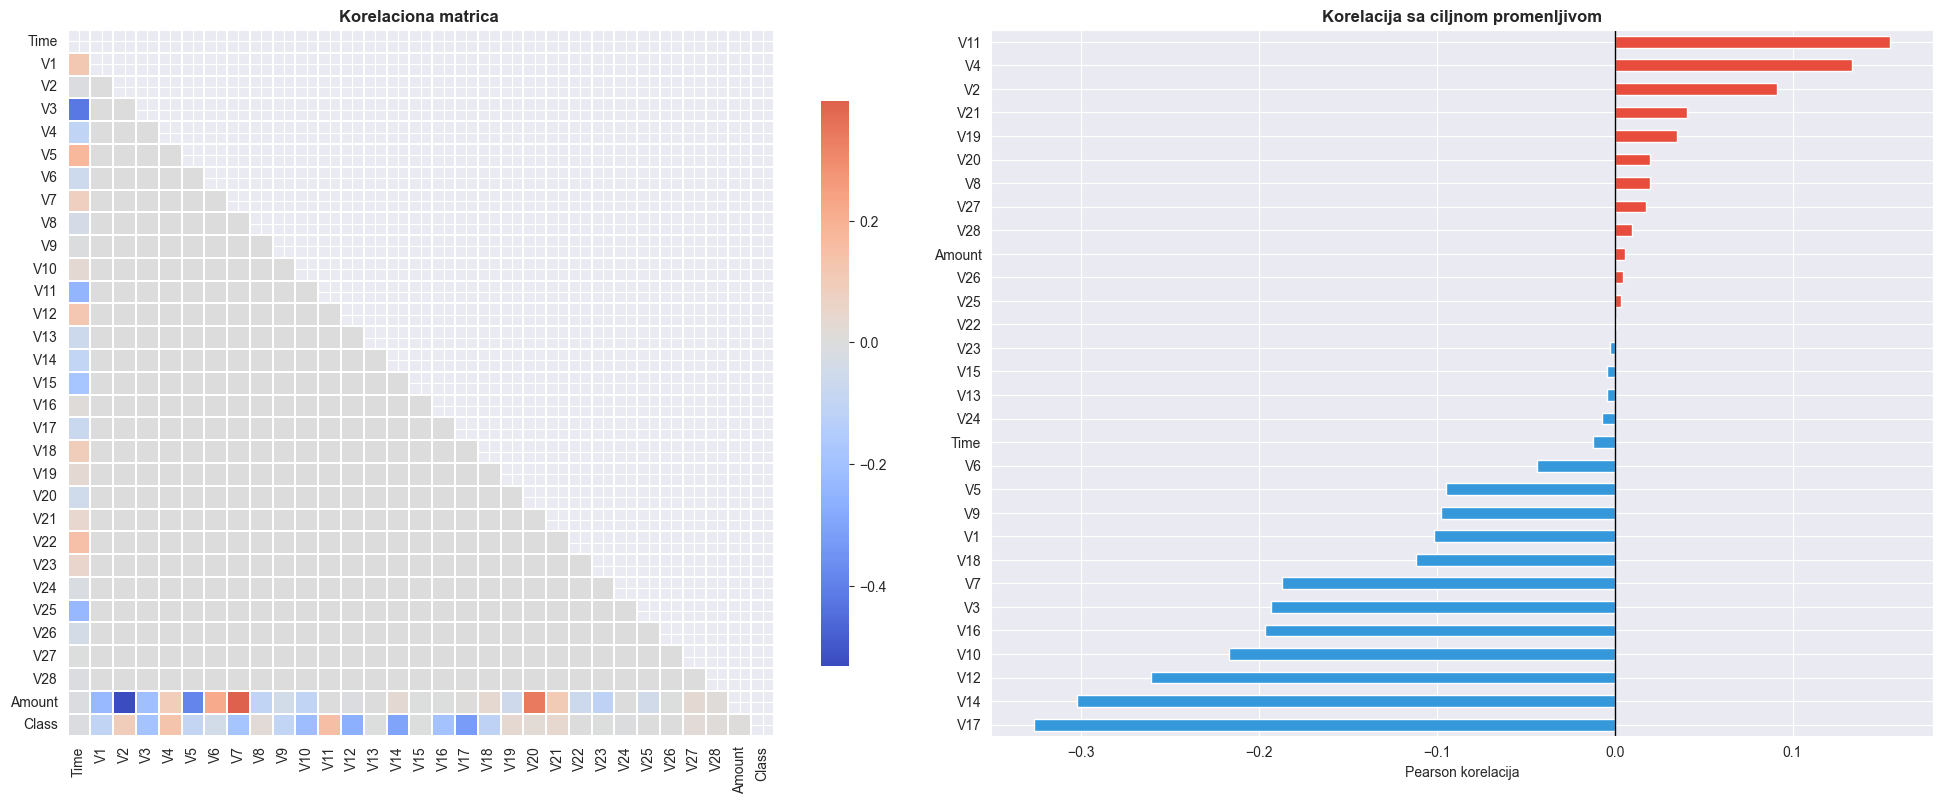

In [14]:
corr = df.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))
sb.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Korelaciona matrica ', fontweight='bold')

target_corr = corr['Class'].drop('Class').sort_values()
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Korelacija sa ciljnom promenljivom', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Pearson korelacija')

plt.tight_layout()
plt.show()

## 8. Outlier analiza

In [15]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['Amount'] < Q1 - 1.5 * IQR) | (df['Amount'] > Q3 + 1.5 * IQR)

print(f'Amount outlier-i (IQR metoda): {outlier_mask.sum():,} ({outlier_mask.mean()*100:.2f}%)')
print(f"Fraud: {df[outlier_mask]['Class'].sum()}")
print(f"Legitimna: {(df[outlier_mask]['Class'] == 0).sum()}")

print(f'\nAmount max vrednosti:')
print(df['Amount'].describe(percentiles=[0.95, 0.99, 0.999]))

Amount outlier-i (IQR metoda): 31,904 (11.20%)
Fraud: 91
Legitimna: 31813

Amount max vrednosti:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
50%          22.000000
95%         365.000000
99%        1017.970000
99.9%      3000.000000
max       25691.160000
Name: Amount, dtype: float64


Rezultati pokazuju da se značajan deo outliera u Amount ne poklapa sa fraud transakcijama, što znači da ekstremne vrednosti iznosa same po sebi nisu dobar indikator prevare. Ipak, prisustvo fraud-a među outlierima sugeriše da visoki iznosi mogu imati određenu, ali ne dominantnu, diskriminativnu ulogu.